# Task 2: Transfer Learning using VGG16

**Objective:** Implement transfer learning using a pretrained VGG16 model and compare its performance with a baseline CNN trained from scratch.

**Dataset:** CIFAR-10 (10 classes of small images)

## Step 1: Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

## Step 2: Load and Explore the Dataset

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1532s 9us/step
Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


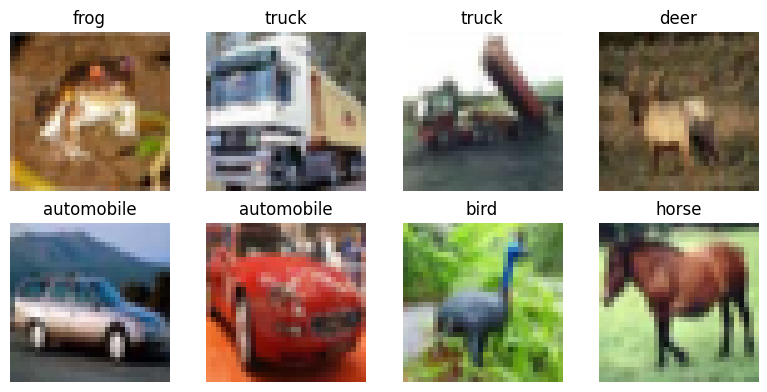

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(8, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()

## Step 3: Preprocess the Data

To keep training fast on a student setup, we use a smaller subset of the dataset.

In [ ]:
# Using a subset of data to keep training time manageable
x_train_small = x_train[:5000]
y_train_small = y_train[:5000]
x_test_small = x_test[:1000]
y_test_small = y_test[:1000]

# Normalize pixel values
x_train_small = x_train_small.astype('float32') / 255.0
x_test_small = x_test_small.astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train_small, 10)
y_test_cat = to_categorical(y_test_small, 10)

print("Train shape:", x_train_small.shape)
print("Test shape:", x_test_small.shape)

Train shape: (5000, 32, 32, 3)
Test shape: (1000, 32, 32, 3)


## Step 4: Build a Baseline CNN (from scratch)

In [ ]:
baseline_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

baseline_model.compile(optimizer=Adam(learning_rate=0.001),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

baseline_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5: Train the Baseline CNN

In [ ]:
start_time = time.time()

baseline_history = baseline_model.fit(x_train_small, y_train_cat,
                                       validation_data=(x_test_small, y_test_cat),
                                       epochs=10,
                                       batch_size=32)

baseline_time = time.time() - start_time
print("Baseline CNN training time: {:.2f} seconds".format(baseline_time))

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.2200 - loss: 2.0986 - val_accuracy: 0.3640 - val_loss: 1.8149
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3418 - loss: 1.7886 - val_accuracy: 0.4480 - val_loss: 1.5821
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3946 - loss: 1.6514 - val_accuracy: 0.4440 - val_loss: 1.5306
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4276 - loss: 1.5747 - val_accuracy: 0.4770 - val_loss: 1.4813
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4586 - loss: 1.4776 - val_accuracy: 0.4960 - val_loss: 1.4200
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4878 - loss: 1.4132 - val_accuracy: 0.5000 - val_loss: 1.3887
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5120 - loss: 1.3449 - val_accuracy: 0.5190 - val_loss: 1.3403
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5336 - loss: 1.2797 - val_accuracy: 0

## Step 6: Build the Transfer Learning Model (VGG16)

We load VGG16 pretrained on ImageNet, freeze its base layers, and add our own classification layers on top.

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Freeze the base layers so their weights are not updated
for layer in base_model.layers:
    layer.trainable = False

vgg_model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

vgg_model.compile(optimizer=Adam(learning_rate=0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Step 7: Train the Transfer Learning Model

In [ ]:
start_time = time.time()

vgg_history = vgg_model.fit(x_train_small, y_train_cat,
                             validation_data=(x_test_small, y_test_cat),
                             epochs=10,
                             batch_size=32)

vgg_time = time.time() - start_time
print("VGG16 transfer learning training time: {:.2f} seconds".format(vgg_time))

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.2814 - loss: 2.0203 - val_accuracy: 0.4000 - val_loss: 1.7021
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4118 - loss: 1.6867 - val_accuracy: 0.4560 - val_loss: 1.5400
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4556 - loss: 1.5585 - val_accuracy: 0.4840 - val_loss: 1.4683
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4852 - loss: 1.4732 - val_accuracy: 0.5060 - val_loss: 1.4245
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5066 - loss: 1.4152 - val_accuracy: 0.5020 - val_loss: 1.3964
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5286 - loss: 1.3622 - val_accuracy: 0.5170 - val_loss: 1.3659
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5368 - loss: 1.3333 - val_accuracy: 0.5280 - val_loss: 1.3538
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5558 - loss: 1.2983 - val_accuracy: 0

## Step 8: Compare Accuracy and Loss

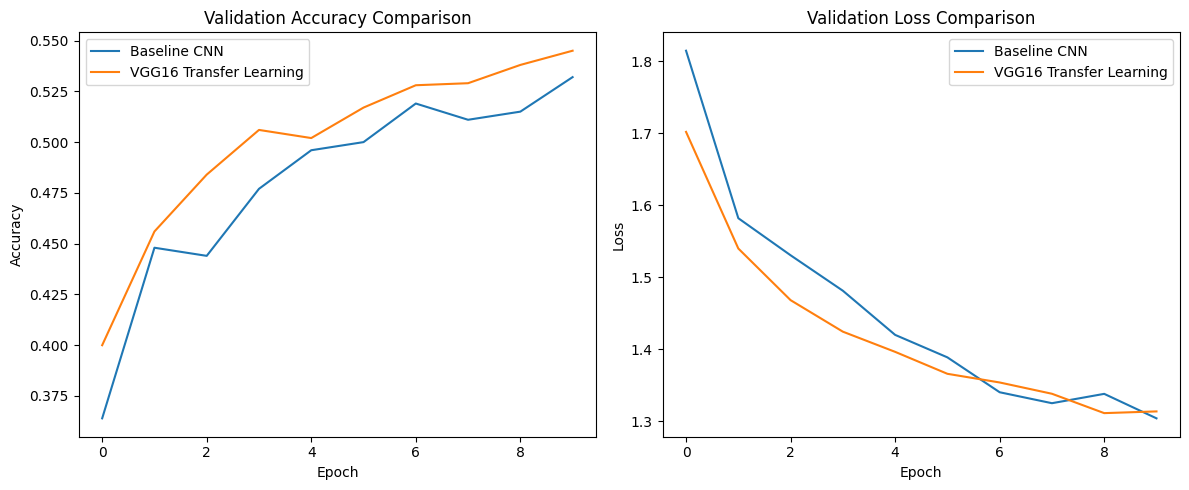

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['val_accuracy'], label='Baseline CNN')
plt.plot(vgg_history.history['val_accuracy'], label='VGG16 Transfer Learning')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['val_loss'], label='Baseline CNN')
plt.plot(vgg_history.history['val_loss'], label='VGG16 Transfer Learning')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Step 9: Compare Training Time and Final Accuracy

In [ ]:
baseline_acc = baseline_history.history['val_accuracy'][-1]
vgg_acc = vgg_history.history['val_accuracy'][-1]

print("Baseline CNN - Final Accuracy: {:.4f}, Training Time: {:.2f}s".format(baseline_acc, baseline_time))
print("VGG16 Transfer Learning - Final Accuracy: {:.4f}, Training Time: {:.2f}s".format(vgg_acc, vgg_time))

Baseline CNN - Final Accuracy: 0.5320, Training Time: 14.74s
VGG16 Transfer Learning - Final Accuracy: 0.5450, Training Time: 22.38s


## Observations

- The baseline CNN was trained from scratch, so it had to learn all features on its own.
- The VGG16 model already had features learned from the large ImageNet dataset, so it could reuse that knowledge (transfer learning).
- Comparing the accuracy and loss plots above shows which model performed better and how fast each one learned.
- Training time also differs since the VGG16 base layers were frozen and only the new top layers were trained.